# Accident Snapping — Test & Visualisation

In [1]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'TH Sarabun New'

import subprocess, sys
result = subprocess.run(
    [sys.executable, "src/geospatial/spatial/snap_accidents.py"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)


/Library/Frameworks/Python.framework/Versions/3.11/Resources/Python.app/Contents/MacOS/Python: can't open file '/Users/biocorn/Documents/GitHub/H-Spot/notebooks/src/geospatial/spatial/snap_accidents.py': [Errno 2] No such file or directory



In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# Set Thai-capable font
plt.rcParams['font.family'] = 'TH Sarabun New'

snapped  = gpd.read_file("../data/processed/accidents_snapped.gpkg")
segments = gpd.read_file("../data/processed/road_segments.gpkg")

matched   = snapped[snapped["segment_id"] != -1]
unmatched = snapped[snapped["segment_id"] == -1]

print(f"Total accidents : {len(snapped):,}")
print(f"Matched         : {len(matched):,} ({len(matched)/len(snapped)*100:.1f}%)")
print(f"Unmatched       : {len(unmatched):,} ({len(unmatched)/len(snapped)*100:.1f}%)")
print(f"Avg snap dist   : {matched['snap_dist_m'].mean():.1f}m")

Total accidents : 12,260
Matched         : 12,260 (100.0%)
Unmatched       : 0 (0.0%)
Avg snap dist   : 4.1m


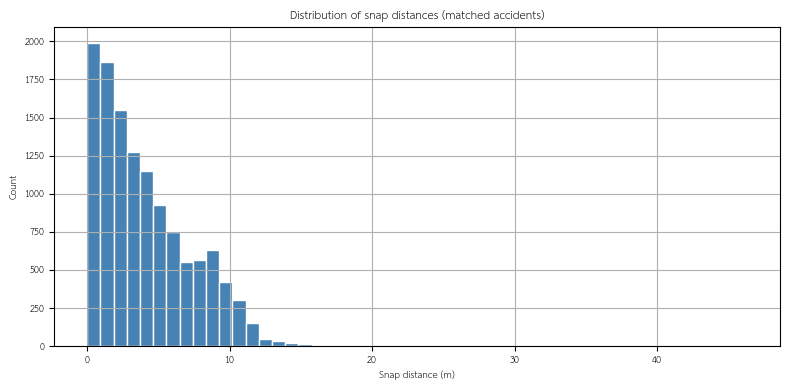

In [3]:
# --- Snap distance distribution ---
fig, ax = plt.subplots(figsize=(8, 4))
matched["snap_dist_m"].hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Snap distance (m)")
ax.set_ylabel("Count")
ax.set_title("Distribution of snap distances (matched accidents)")
plt.tight_layout()
plt.show()

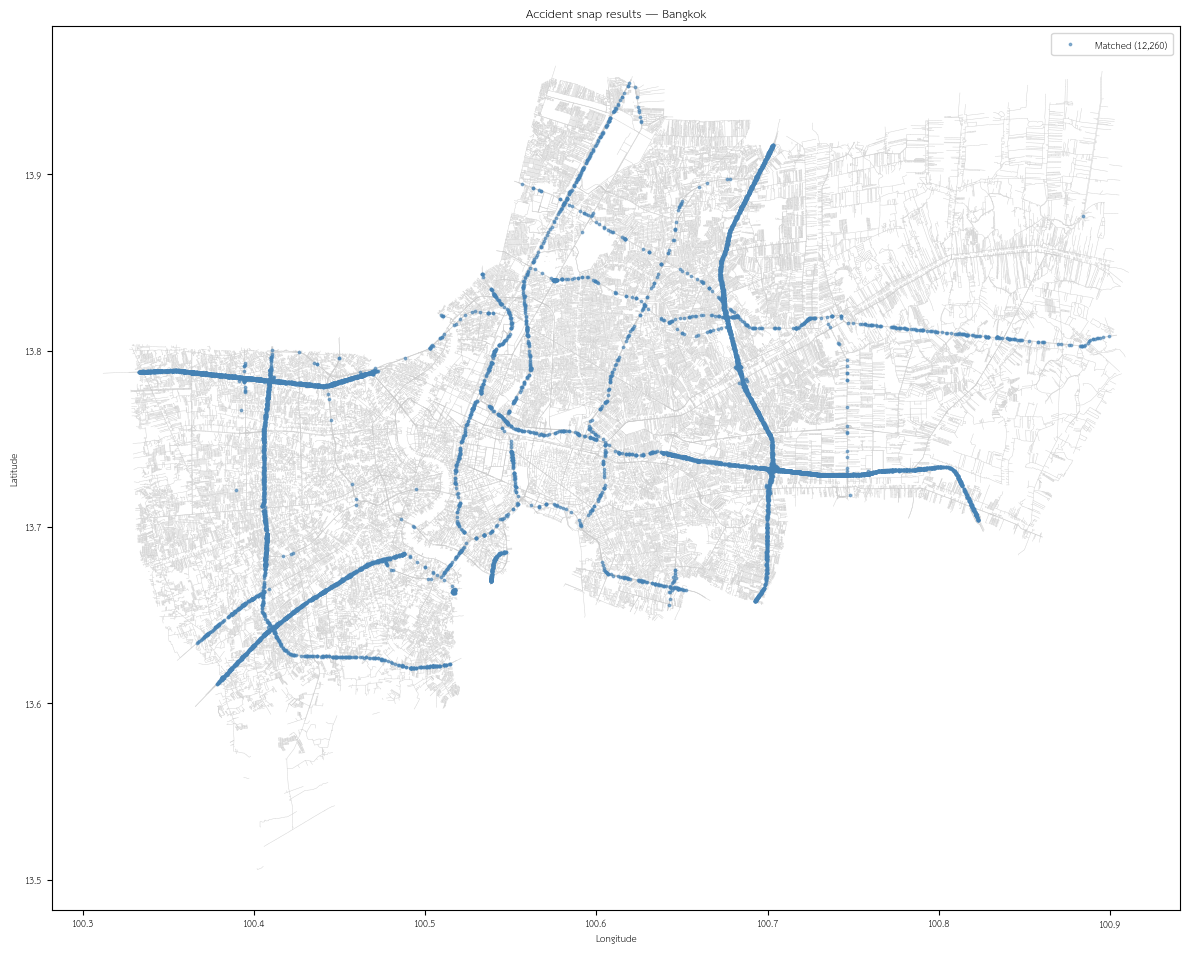

In [4]:
# --- Full Bangkok: matched (blue) vs unmatched (red) ---
segs_wgs      = segments.to_crs("EPSG:4326")
matched_wgs   = matched.to_crs("EPSG:4326")
unmatched_wgs = unmatched.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(12, 12))
segs_wgs.plot(ax=ax, color="#cccccc", linewidth=0.3, zorder=1)
matched_wgs.plot(ax=ax, color="steelblue", markersize=3, alpha=0.6,
                 zorder=2, label=f"Matched ({len(matched_wgs):,})")
if len(unmatched_wgs) > 0:
    unmatched_wgs.plot(ax=ax, color="red", markersize=3, alpha=0.6,
                       zorder=3, label=f"Unmatched ({len(unmatched_wgs):,})")
ax.legend(fontsize=10)
ax.set_title("Accident snap results — Bangkok", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

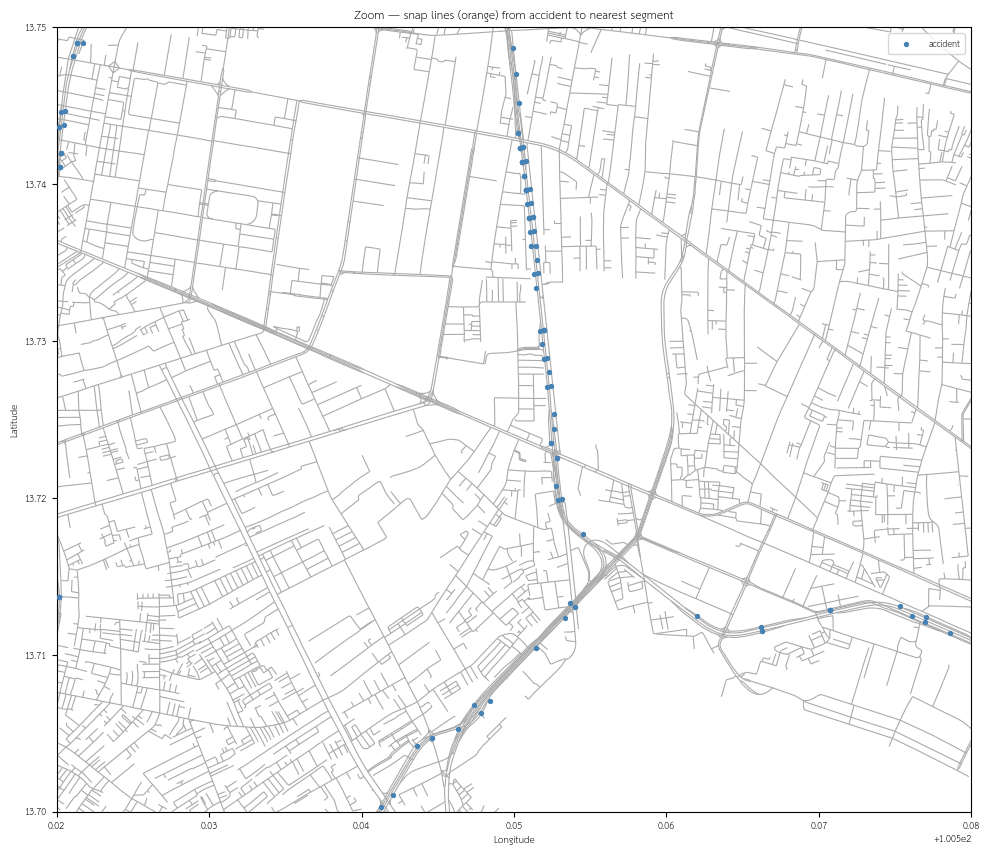

Accidents in view: 115


In [5]:
# --- Zoom: central Bangkok, show snap lines ---
from shapely.geometry import LineString

ZOOM = (100.52, 13.70, 100.58, 13.75)

segs_zoom    = segs_wgs.cx[ZOOM[0]:ZOOM[2], ZOOM[1]:ZOOM[3]]
matched_zoom = matched_wgs.cx[ZOOM[0]:ZOOM[2], ZOOM[1]:ZOOM[3]]

# Build snap lines: accident point → nearest point on segment
matched_proj = matched_zoom.to_crs("EPSG:32647")
segs_proj    = segments[segments["segment_id"].isin(matched_zoom["segment_id"])]
seg_lookup   = segs_proj.set_index("segment_id")["geometry"]

snap_lines = []
for _, row in matched_proj.iterrows():
    seg_geom = seg_lookup.get(row["segment_id"])
    if seg_geom is not None:
        nearest_pt = seg_geom.interpolate(seg_geom.project(row.geometry))
        snap_lines.append(LineString([row.geometry, nearest_pt]))

import geopandas as gpd
snap_gdf = gpd.GeoDataFrame(geometry=snap_lines, crs="EPSG:32647").to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 10))
segs_zoom.plot(ax=ax, color="#aaaaaa", linewidth=0.8, zorder=1)
snap_gdf.plot(ax=ax, color="orange", linewidth=0.8, alpha=0.7, zorder=2)
matched_zoom.plot(ax=ax, color="steelblue", markersize=8, zorder=3, label="accident")
ax.set_xlim(ZOOM[0], ZOOM[2])
ax.set_ylim(ZOOM[1], ZOOM[3])
ax.set_title("Zoom — snap lines (orange) from accident to nearest segment", fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"Accidents in view: {len(matched_zoom):,}")

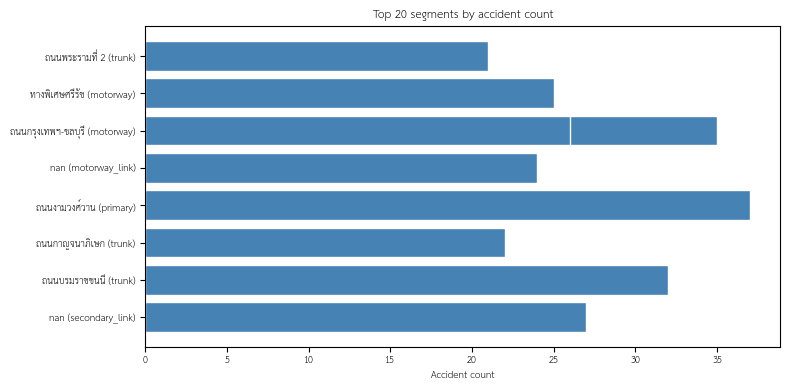

In [6]:
# --- Accidents per segment (top 20 hotspot segments) ---
acc_per_seg = matched.groupby("segment_id").size().reset_index(name="accident_count")
top20 = acc_per_seg.nlargest(20, "accident_count")

top20_segs = segments[segments["segment_id"].isin(top20["segment_id"])].merge(
    top20, on="segment_id"
)

fig, ax = plt.subplots(figsize=(8, 4))
labels = top20_segs.apply(
    lambda r: f"{r['name'] or 'unnamed'} ({r['highway']})", axis=1
)
ax.barh(labels, top20_segs["accident_count"], color="steelblue", edgecolor="white")
ax.set_xlabel("Accident count")
ax.set_title("Top 20 segments by accident count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()